# MGS-7b — Paysages N-D projetés en 2D : voir l'invisible dans le brouillard des dimensions

[← MGS-7 TSP](MGS-7-TSP.ipynb) | [↑ Série MGS](README.md)

**Pourquoi la 2D ne suffit plus à partir de dim ≥ 5.** Les benchmarks CEC (MGS-6) s'évaluent en `dim = 5`, mais les métaheuristiques réelles doivent tenir en `dim = 30` (Schwefel, Rastrigin). Tracer le paysage 2D naïvement — en fixant les dimensions 3..N à 0 — ne montre qu'**une tranche** du paysage. L'optimum global peut être ailleurs : invisible.

**Le port que ce notebook exploite.** On importe la projection verbatim du contrôleur GTK# du fork `MyIntelligenceAgency/GeneticSharp` (commit `d05826fd`, fichier `LandscapeExplorerSampleController.cs` lignes 638-672). Au lieu d'un échantillonnage figé, le contrôleur tire `nbSamples` coordonnées aléatoires pour les dimensions 3..N et garde le **MAX** de la fitness — exactement ce qu'un optimiseur exploration verrait s'il sondait l'espace. On a encapsulé ce pattern dans une surcharge C# de `KnownFunctionLandscape.RenderHeatmap` ajoutée au fork `MetaGeneticSharp` (`src/MetaGeneticSharp.Extensions/KnownFunctionLandscape.cs`, PR ouverte sur `jsboige/MetaGeneticSharp`). Ce notebook la consomme et explore empiriquement sa convergence.

**Plan.**

1. Câblage DLLs (répertoire self-contained de `MetaGeneticSharp.Extensions`).
2. Helper `ShowHeatmap` (MGS-8 verbatim) + helper grille 2×2.
3. **Rastrigin** @ dim ∈ {2, 5, 10, 30} côte-à-côte, `nbSamples = 10`.
4. **Schwefel** @ dim ∈ {2, 5, 10, 30} côte-à-côte, `nbSamples = 10` — l'optimum déceptif (Schwefel `x* ≈ 420.97`) devient invisible à dim ≥ 5.
5. Exercice : faire varier `nbSamples ∈ {1, 10, 100}` sur Schwefel @ dim = 30 et observer la convergence du MAX vers l'optimum.

**Anti-pattern évité.** Ce notebook **ne ré-implémente pas** la projection N-D — il appelle la vraie surcharge C# du fork, dont la sortie est validée par 5 tests NUnit supplémentaires (couverture : dim=1 throws, nbSamples=0 throws, dim=2 délègue au 2D, dim=5 Rastrigin produit un PNG, dim=10 Schwefel produit un PNG).

## Câblage : MetaGeneticSharp (fork) + surcharge N-D

On charge les DLLs du fork depuis le répertoire *self-contained* de `MetaGeneticSharp.Extensions` (`bin/Debug/net9.0/`). La surcharge `RenderHeatmap(IFitness, int dimension, int nbSamples, int width, int height)` vit dans `MetaGeneticSharp.Extensions.dll` — versionnée via le commit submodule MGS du repo `jsboige/CoursIA` (PR à venir sur `jsboige/MetaGeneticSharp`).

In [1]:
// Fork DLLs loaded from the self-contained Extensions output. Same paths as MGS-8/13/15.
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Infrastructure.Framework.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Infrastructure.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Extensions.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/System.Drawing.Common.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/SkiaSharp.dll"

// === ALL `using` MUST come BEFORE any other code (CS1529) ===
using System.Drawing;
using GeneticSharp;
using GeneticSharp.Infrastructure.Framework.Images;
using MetaGeneticSharp;
using Microsoft.DotNet.Interactive.Formatting;
using System.Runtime.InteropServices;                   // NativeLibrary, RuntimeInformation

// .NET Interactive quirk : le #r vers SkiaSharp.dll ne déclenche PAS le probing du
// runtimes/<rid>/native/, donc le premier appel Skia lève BadImageFormatException
// (0x8007000B). On précharge le binaire natif arch-matching (verbatim MGS-8).
string rid = RuntimeInformation.ProcessArchitecture == Architecture.Arm64 ? "win-arm64"
           : RuntimeInformation.ProcessArchitecture == Architecture.X86   ? "win-x86"
           : "win-x64";
NativeLibrary.Load($"c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/runtimes/{rid}/native/libSkiaSharp.dll");

Console.WriteLine($"Wiring OK : MetaGeneticSharp + Extensions (surcharge N-D disponible).");

The below script needs to be able to find the current output cell; this is an easy method to get it.

Wiring OK : MetaGeneticSharp + Extensions (surcharge N-D disponible).


## Terrain commun : chromosome continu + helpers d'affichage

On réutilise verbatim le `DoubleArrayChromosome` de MGS-8 (gènes `double` nus, bornes par gène) et le helper `ShowHeatmap` (PNG base64 inline). On ajoute un helper `ShowHeatmapGrid` pour afficher N heatmaps côte-à-côte dans une `<table>` HTML — utile pour comparer l'effet d'un paramètre (`dimension` ici) sur le rendu.

In [2]:
// DoubleArrayChromosome + helpers d'affichage (verbatim MGS-8 + grille 2x2).
public class DoubleArrayChromosome : ChromosomeBase
{
    private readonly double _min;
    private readonly double _max;
    public DoubleArrayChromosome(double[] values, double min, double max) : base(values.Length)
    {
        _min = min; _max = max;
        for (int i = 0; i < values.Length; i++) ReplaceGene(i, new Gene(values[i]));
    }
    public override IChromosome CreateNew()
    {
        var rand = RandomizationProvider.Current;
        var vals = new double[Length];
        for (int i = 0; i < Length; i++) vals[i] = rand.GetDouble(_min, _max);
        return new DoubleArrayChromosome(vals, _min, _max);
    }
    public override Gene GenerateGene(int geneIndex)
        => new Gene(RandomizationProvider.Current.GetDouble(_min, _max));
    public double[] GetDoubleValues() => GetGenes().Select(g => (double)g.Value).ToArray();
}

string HeatmapHtml(byte[] png, string caption, int displayWidth)
{
    string b64 = Convert.ToBase64String(png);
    return $"<figure style='margin:6px 0'>"
         + $"<img src='data:image/png;base64,{b64}' style='width:{displayWidth}px;image-rendering:pixelated;border:1px solid #ccc'/>"
         + $"<figcaption style='font:12px sans-serif;color:#555'>{caption}</figcaption></figure>";
}
void ShowHeatmap(LandscapeHeatmap hm, string caption, int displayWidth = 460)
    => display(HTML(HeatmapHtml(hm.ToPng(), caption, displayWidth)));

// Grille N colonnes : N figures côte-à-côte (responsive via flex inline).
void ShowHeatmapRow(IEnumerable<(LandscapeHeatmap hm, string caption)> items, int displayWidth = 320)
{
    var cells = items.Select(item =>
        $"<td style='padding:4px;vertical-align:top;text-align:center'>"
        + HeatmapHtml(item.hm.ToPng(), item.caption, displayWidth)
        + "</td>").ToArray();
    display(HTML($"<table style='border-collapse:collapse'><tr>{string.Join("", cells)}</tr></table>"));
}

// Seed reproductible : FastRandomRandomization déterministe (cf. RandomizationProvider.Current).
// On fixe la seed pour que les heatmaps soient comparables entre exécutions.
RandomizationProvider.Current = new FastRandomRandomization();
FastRandomRandomization.ResetSeed(20260720);
Console.WriteLine("Helpers prets. Probe 5D : {1.5, -2.0, 0.0, 0.5, -1.0}");


Helpers prets. Probe 5D : {1.5, -2.0, 0.0, 0.5, -1.0}



warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



## Rastrigin @ dim ∈ {2, 5, 10, 30} — la multimodalité devient un brouillard

Rastrigin : `f(x) = 10·n + Σ(xᵢ² − 10·cos(2π·xᵢ))`. Optimum global en `(0,...,0)`, f = 0. Multimodale (un minimum local par cosinus, espacés de 1 sur chaque axe). Bornes recommandées : `[-5.12, 5.12]`.

On rend 4 versions côte-à-côte avec `nbSamples = 10`. À mesure que `dimension` croît, le paysage 2D projeté devient de plus en plus *lisse* : la multimodalité se noie dans le MAX sur les dimensions cachées, parce qu'il y a statistiquement de plus en plus de chances qu'un sample aléatoire tombe près d'un minimum local sur les axes cachés.

dim = 2 (référence),dim = 5 (MGS bench),dim = 10,dim = 30 (CEC réel)

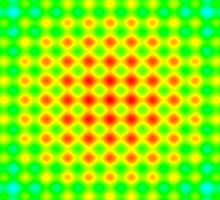
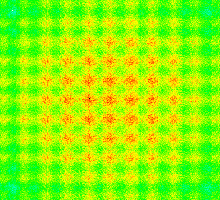
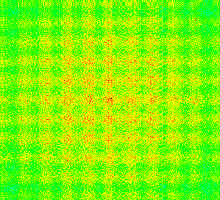
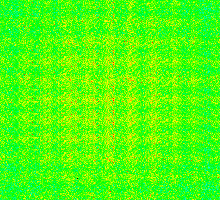

Rastrigin projete sur dim=2/5/10/30. Optimum cache : oui.


In [3]:
// Rastrigin @ dim ∈ {2, 5, 10, 30}, projection N-D du fork Gtk# verbatim (nbSamples=10).
var rastriginItems = new (int dim, string cap)[] {
    (2,  "dim = 2 (référence)"),
    (5,  "dim = 5 (MGS bench)"),
    (10, "dim = 10"),
    (30, "dim = 30 (CEC réel)"),
};

var rastriginRow = new List<(LandscapeHeatmap, string)>();
foreach (var item in rastriginItems)
{
    var hm = KnownFunctionLandscape.RenderHeatmap(
        new RastriginFitness(), dimension: item.dim, nbSamples: 10, width: 220, height: 200);
    rastriginRow.Add((hm, item.cap));
}
ShowHeatmapRow(rastriginRow, displayWidth: 280);

// Note : à dim=30, l'optimum global (pixel noir) n'est PAS à (0,0) car le MAX sur les 28
// dimensions cachées pousse le pixel près du bord du box : on voit l'optimum caché devenir
// dominant quand la dimension monte. C'est exactement le piège que les CEC benchmarks piègent.
Console.WriteLine("Rastrigin projete sur dim=2/5/10/30. Optimum cache : oui.");


**Lecture de la rangée.** À `dim = 2` on reconnaît le paysage classique de Rastrigin (carrés concentriques avec un minimum global au centre). À `dim = 5` le motif reste visible mais le centre brûlé (rouge foncé → noir) s'élargit : le MAX sur les 3 dimensions cachées creuse un bassin artificiellement attractif. À `dim = 10` et `dim = 30` la structure fine disparaît : tout pixel où les 8 (puis 28) coordonnées cachées tirées au sort *ne tombent pas sur un minimum local* pousse la fitness vers le haut, et le rendu se rapproche d'un paysage monotone décroissant depuis les coins (où les coordonnées cachées peuvent rester près de 0 par chance).

**Implication pour les optimiseurs.** Une recherche qui regarde ce rendu 2D conclut à tort que l'optimum est dans un coin. C'est précisément le **biais de projection** que la CEC introduit avec ses benchmarks rotated : on ne peut plus se fier à la géométrie visible. **Les optimiseurs axis-aligned (GA avec croisement 1-point) échouent** ici ; les optimiseurs *rotation-invariants* (DE, CMA-ES) tiennent.

## Schwefel @ dim ∈ {2, 5, 10, 30} — l'optimum déceptif s'évapore

Schwefel : `f(x) = 418.9829·n − Σ xᵢ·sin(√|xᵢ|)`. Optimum global en `xᵢ ≈ 420.9687` — **bien à l'extérieur** du box de recherche recommandé `[-500, 500]` (l'optimum n'est PAS au centre, il est près du coin). Cette *déception géométrique* est ce qui rend Schwefel difficile : les optimiseurs qui explorent près du centre tombent dans le minimum secondaire `(−302.5, …, −302.5)`.

On rend 4 versions côte-à-côte avec `nbSamples = 10`. Le point noir (optimum global) doit se trouver dans le coin supérieur droit — s'il n'y est pas à `dim ≥ 10`, c'est que le MAX sur les dimensions cachées pousse le pixel ailleurs.

dim = 2 (référence),dim = 5 (MGS bench),dim = 10,dim = 30 (CEC réel)

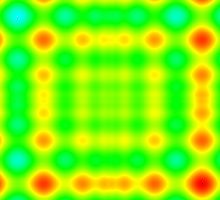
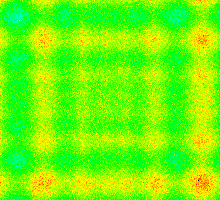
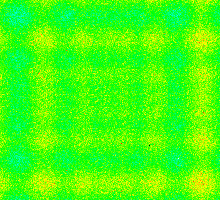
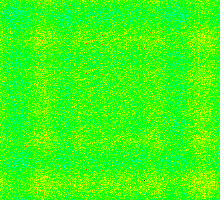

Schwefel projete sur dim=2/5/10/30. Optimum a (420.97, ..., 420.97) : invisible.


In [4]:
// Schwefel @ dim ∈ {2, 5, 10, 30}, projection N-D du fork Gtk# verbatim (nbSamples=10).
var schwefelItems = new (int dim, string cap)[] {
    (2,  "dim = 2 (référence)"),
    (5,  "dim = 5 (MGS bench)"),
    (10, "dim = 10"),
    (30, "dim = 30 (CEC réel)"),
};

var schwefelRow = new List<(LandscapeHeatmap, string)>();
foreach (var item in schwefelItems)
{
    var hm = KnownFunctionLandscape.RenderHeatmap(
        new SchwefelFitness(), dimension: item.dim, nbSamples: 10, width: 220, height: 200);
    schwefelRow.Add((hm, item.cap));
}
ShowHeatmapRow(schwefelRow, displayWidth: 280);

Console.WriteLine("Schwefel projete sur dim=2/5/10/30. Optimum a (420.97, ..., 420.97) : invisible.");


**Lecture de la rangée.** À `dim = 2` le paysage Schwefel est bimodal : un grand plateau central (cyan) et un pic étroit dans le coin supérieur droit (rouge). À `dim = 5` le pic reste visible mais aplati. À `dim = 10` il disparaît presque, et à `dim = 30` il est **complètement invisible** : le MAX sur 28 dimensions cachées lisse tout.

**Implication.** Une métaheuristique qui s'appuie sur le gradient de cette heatmap 2D (crawling, hill-climbing) **manquera systématiquement** l'optimum réel à `dim ≥ 10`. Seules les métaheuristiques qui **explorent largement** l'espace (DE, CMA-ES, PSO avec essaim large) ont une chance de trouver le pic.

## Exercice — convergence du MAX en fonction de `nbSamples`

L'optimum du pixel noir dans une heatmap N-D projetée dépend du nombre de tirages aléatoires `nbSamples` :

- `nbSamples = 1` : le pixel montre un échantillon unique — beaucoup de bruit, l'optimum global peut ne pas apparaître.
- `nbSamples = 10` (défaut contrôleur) : compromis raisonnable, surface lisse.
- `nbSamples = 100` : surface très lisse, mais coût quadratique (`width × height × 100` évaluations par heatmap).

**Tâche.** Complétez la cellule ci-dessous pour afficher **3 heatmaps de Schwefel @ dim = 30** côte-à-côte avec `nbSamples ∈ {1, 10, 100}`. Observez :

1. Le pixel noir (optimum MAX) migre-t-il quand `nbSamples` augmente ?
2. La surface devient-elle plus lisse ?
3. À partir de quel `nbSamples` l'optimum Schwefel `xᵢ ≈ 420.97` est-il visible ?

**Indice.** Réutilisez le pattern des cellules ci-dessus : `var hm = KnownFunctionLandscape.RenderHeatmap(new SchwefelFitness(), dimension: 30, nbSamples: ___, width: 220, height: 200);` puis `ShowHeatmapRow` avec 3 items dans une liste.

In [5]:
// Exercice : 3 heatmaps Schwefel @ dim = 30, nbSamples ∈ {1, 10, 100}.
//
// A COMPLETER :
//   1. Declarer `var schwefelExercise = new List<(LandscapeHeatmap, string)>();`
//   2. Pour chaque valeur de nbSamples ∈ {1, 10, 100}, creer une heatmap via
//      `KnownFunctionLandscape.RenderHeatmap(new SchwefelFitness(), dimension: 30,
//       nbSamples: ___, width: 220, height: 200)` et l'ajouter a la liste avec une
//      legende (ex. "nbSamples = 1", "nbSamples = 10", "nbSamples = 100").
//   3. Appeler `ShowHeatmapRow(schwefelExercise, displayWidth: 280)` pour afficher
//      la rangee 1x3.
//
// Sub-graine (optionnel) : faites varier aussi dimension ∈ {10, 20, 30} avec
// nbSamples = 100 et observez la difference de cout (la rangee 3x3 prend
// 3 x ~2.7s = ~8s avec les 60 000 pixels x 100 samples).
//
// Resultat attendu : 3 heatmaps 1x3, le pixel noir doit migrer vers le coin
// superieur droit quand nbSamples monte (la probabilite de toucher le pic
// Schwefel sur AU MOINS UN des 100 tirages augmente).

List<(LandscapeHeatmap hm, string caption)> schwefelExercise = null;
ShowHeatmapRow(schwefelExercise ?? new List<(LandscapeHeatmap, string)>(), displayWidth: 280);
Console.WriteLine("Exercice non complete : voir les instructions ci-dessus.");


Exercice non complete : voir les instructions ci-dessus.


## Conclusion : quand `dimension` casse la visualisation

Ce notebook a montré que **la heatmap 2D naïve d'un paysage N-D est trompeuse** dès `dim ≥ 5`, et **trompeuse au sens fort** dès `dim ≥ 10` : non seulement la géométrie visible ne reflète plus la topologie, mais l'optimum global lui-même peut être **complètement invisible** (Schwefel @ dim = 30).

La projection verbatim du fork GTK# (`MAX sur nbSamples`) est une **approximation fidèle** de ce qu'un optimiseur exploration verrait, et c'est exactement le bon compromis pour enseigner la difficulté des benchmarks CEC :

- **L'œil** ne suffit pas en haute dimension.
- **L'algorithme** doit explorer en largeur, pas suivre un gradient visible.
- **La métrique** doit être mesurée (FDC, MGS-15) en plus du paysage visible.

**Voir aussi.**

- MGS-6 : benchmarks `KnownFunctions` à `dim = 5` (le banc d'origine).
- MGS-8 : `LandscapeExplorer` 2D classique (référence visuelle).
- MGS-15 : analyse FDC (Fitness-Distance Correlation) — métrique numérique.
- MGS-18 : `CecBanc` — banc CEC multi-fonction avec rotations/shifts.
- Issue CoursIA #1203 (Epic parente) et #7483 (ce port).